# Stage 3 — Initial Clustering

**Input**: Per-ROI feature CSVs from `stage2_features/<machine>/` (or `feature_csv_dir` in config)  
**Output**: `adata.h5ad`, dot plot, heatmap, `top_markers.csv`, per-ROI cluster assignment CSVs  
**Scope**: Per machine — select which machine to cluster below.

In [8]:
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import display

from pipeline.config import load_config
from pipeline.io import (
    combine_feature_files,
    discover_feature_files,
    save_adata,
    save_roi_assignments,
)
from pipeline.preprocessing import (
    clean_column_names,
    select_features,
    build_adata,
    double_z_norm,
)
from pipeline.clustering import (
    run_leiden_pipeline,
    compute_top_markers,
    prepare_cluster_means,
)
from pipeline.visualization import plot_dotplot, plot_heatmap, plot_spatial

cfg = load_config("config.yaml")
np.random.seed(cfg.clustering.random_seed)

## Select Machine

Set the machine to cluster. Must match a key in `config.yaml → machines`.

In [9]:
# ── Select which machine to process ──
MACHINE = list(cfg.machines.keys())[0]  # Change this or pick from list
print(f"Available machines: {list(cfg.machines.keys())}")
print(f"Selected machine: {MACHINE}")

machine_cfg = cfg.machines[MACHINE]
input_dir = machine_cfg.feature_csv_dir
output_dir = cfg.ensure_stage_dir(3, MACHINE)
print(f"Input dir:  {input_dir}")
print(f"Output dir: {output_dir}")

Available machines: ['machine_A', 'machine_B']
Selected machine: machine_A
Input dir:  ./data/raw/mrd_A
Output dir: experiments/exp-04-03-2026/stage3_clustering/machine_A


## Load & Prepare Data

In [10]:
# Discover and load feature files
feature_files, region_list = discover_feature_files(input_dir)
print(f"Found {len(feature_files)} ROI files")

df = combine_feature_files(input_dir, feature_files, region_list)
print(f"Combined shape: {df.shape}")

# Clean column names (strip "Biomarker Exp" suffix)
df = clean_column_names(df)

# Split into selected features, unselected features, metadata
selected_markers = cfg.selected_markers
meta_columns = cfg.meta_columns

selected_feat_exp, unselected_feat_exp, metadata = select_features(
    df, selected_markers, meta_columns
)

print(f"Selected markers: {len(selected_markers)}")
print(f"Unselected features: {len(unselected_feat_exp.columns)}")
display(selected_feat_exp.head())

Found 34 ROI files
Dropping 55 DAPI autofluorescence columns
Combined shape: (155883, 93)
Selected markers: 25
Unselected features: 63


,Arginase 1 REAL1137,CD11b REA1321,CD11c REA1310,CD14 REA1314,CD15 VIMC6,CD16 REA1324,CD163 REA1309,CD20 REAL1069,CD235a REA175,CD3 REAL1097,...,CD68 REAL1346,CD73 REAL1172,Alexa647 anti rabbit1,CD8a REA1024,FoxP3 REA1253,HLA DR REAL550,Ki 67 REAL1047,Mast Cell Tryptase REAL798,PAX 5 REA140,Podoplanin REA446
0,142.612549,368.542603,256.495056,419.692383,1179.191895,867.141724,1053.285156,56.929150,57.007175,197.064575,...,158.090576,525.380249,90.024223,177.217041,28.564848,686.254700,1197.146606,1020.531982,36.905453,53.105831
1,98.813652,182.569885,181.781143,212.880829,1041.951294,254.093170,144.199356,38.466957,92.556877,152.503799,...,63.039001,439.611053,89.054863,438.328278,32.968750,165.169022,1071.879883,667.941895,32.217106,25.396534
2,105.855972,179.359329,156.095825,239.874084,759.077393,403.440826,391.545441,39.325737,57.259712,89.924629,...,72.075668,796.399353,124.555702,96.134674,34.663013,332.556244,1228.556274,869.562134,37.394367,23.165352
3,51.352497,50.098492,69.110275,47.407162,235.882660,76.155983,167.249771,19.904335,32.269558,22.201225,...,35.089066,189.460892,38.079666,31.988689,25.926477,59.820454,14613.852539,644.547302,14.846272,12.682375
4,138.536926,206.991104,232.609879,645.010681,857.938599,665.995117,1795.711304,71.385674,84.006226,96.928825,...,140.979538,927.568481,219.498505,60.247330,32.885483,739.266479,1240.225220,854.581787,37.324867,35.548931


In [11]:
# Build AnnData (normalises selected features internally)
adata = build_adata(selected_feat_exp, metadata, selected_markers)

# Store unselected features in obs for later use
unselected_features = list(unselected_feat_exp.columns)
for col in unselected_features:
    adata.obs[col] = unselected_feat_exp[col].values

display(adata)

AnnData object with n_obs × n_vars = 155883 × 25
    obs: 'AKT Pan REA676', 'Actin REAL650', 'BATF REA486', 'Bcl 2 REA872', 'CD104 REA236', 'CD117 REA787', 'CD123 REA918', 'CD134 ACT35', 'CD147 REA282', 'CD181 REA958', 'CD182 REA208', 'CD183 REAL756', 'CD195 REA245', 'CD196 REA190', 'CD1c REAL1005', 'CD2 REA1130', 'CD202b REA198', 'CD204 REA460', 'CD209 REAL690', 'CD223 REA351', 'CD226 REA1040', 'CD23 REAL1096', 'CD244 REAL1225', 'CD247 REAL1135', 'CD271 REAL709', 'CD274 REA1308', 'CD279 PD1 3 1 3', 'CD295 REA361', 'CD305 REA447', 'CD317 REA202', 'CD43 REA833', 'CD44 REA690', 'CD45RA REAL164', 'CD45RO REA611', 'CD52 REA164', 'CD56 REAL1142', 'CD57 REA769', 'CD79a REA1168', 'CD88 REA1213', 'CD90 REAL677', 'CD99 REA1174', 'Cell Id', 'EZH2 REA907', 'EmptyPE1', 'FAK pS910 REA407', 'FcepsilonRIalpha REA758', 'Galectin 9 REA435', 'IFN gamma REAL788', 'IRF 7 REA521', 'JNK1 REAL1128', 'JNK2 REA1153', 'NPM1mut primaryRab400 polyclonal', 'Nuc X', 'Nuc Y Inv', 'Nucleophosmin REAL823', 'PCNA REA85

## Clustering (PCA → KNN → Leiden)

In [12]:
adata = run_leiden_pipeline(
    adata,
    n_neighbors=cfg.clustering.n_neighbors,
    n_pcs=cfg.clustering.n_pcs,
    resolution=cfg.clustering.resolution,
    random_seed=cfg.clustering.random_seed,
)

print(f"\nCluster distribution:")
display(adata.obs["leiden"].value_counts())


Cluster distribution:


leiden
0     14106
1     12302
2     11317
3     10445
4      8564
5      7918
6      7581
7      7349
8      6063
9      5652
10     5139
11     4988
12     4937
13     4657
14     4405
15     4073
16     3807
17     3658
18     3641
19     3510
20     3467
21     3327
22     3267
23     3120
24     2863
25     2033
26     1686
27      709
28      566
29      277
30      217
31      122
32      117
Name: count, dtype: int64

## Visualisation: Dot Plot & Heatmap

/home/hp/projects/multiplex_imaging_analysis/pipeline/clustering.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = expr_df.groupby(cluster_key).mean()


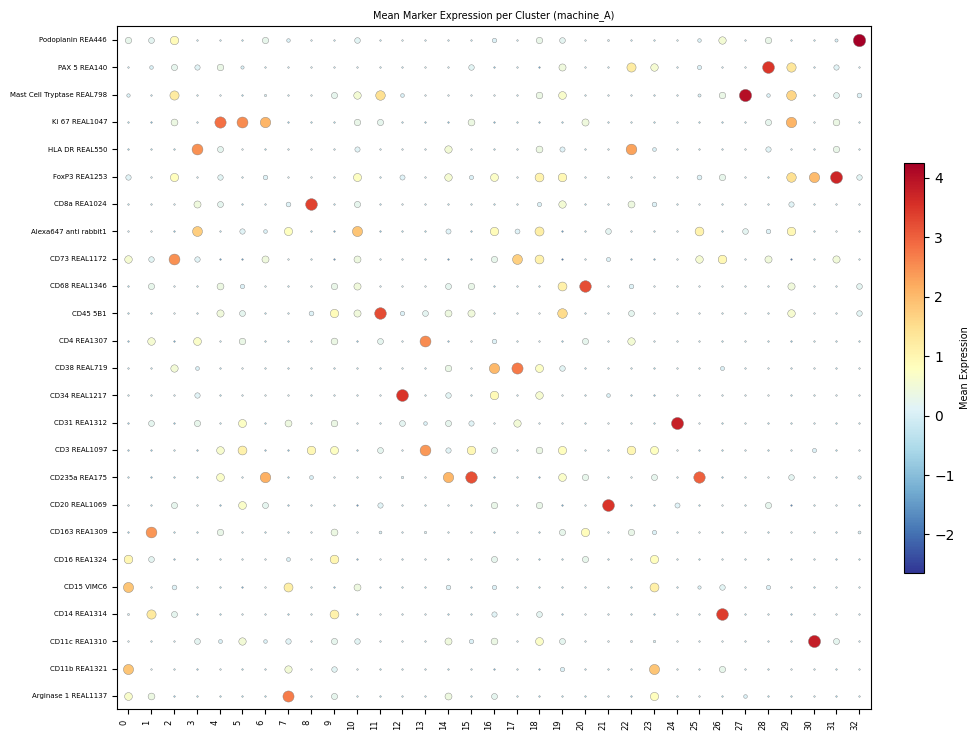

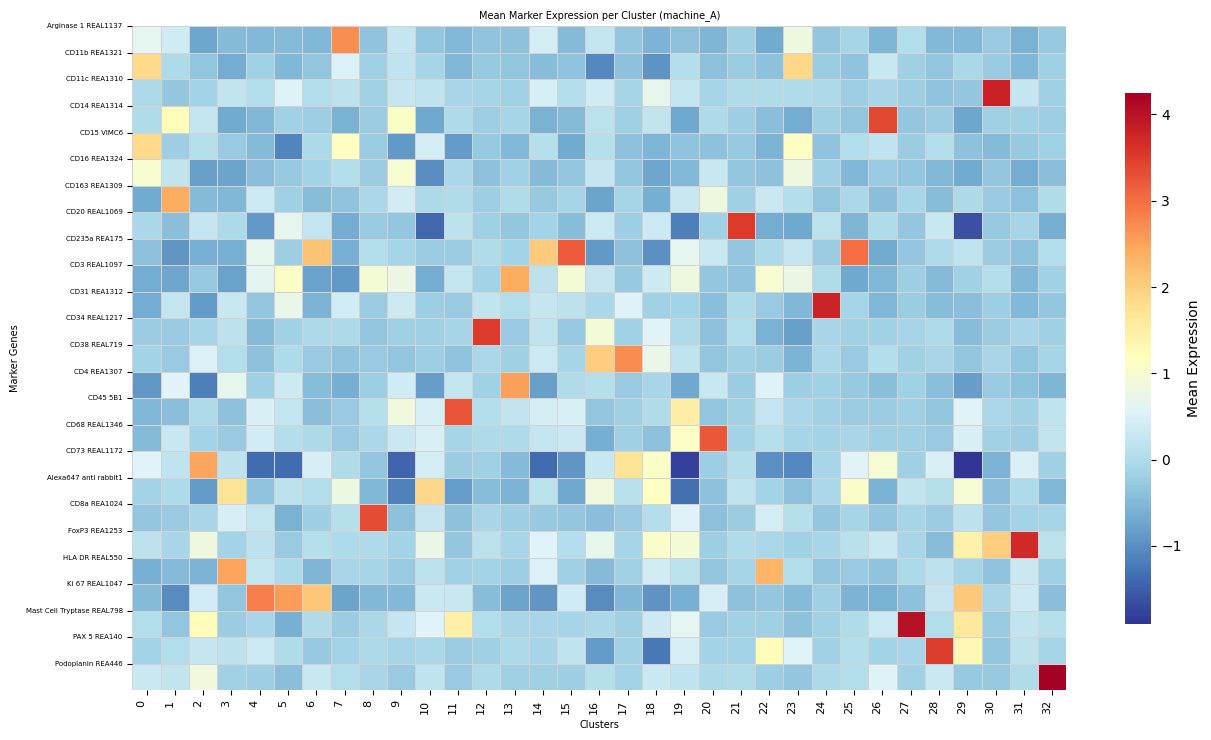

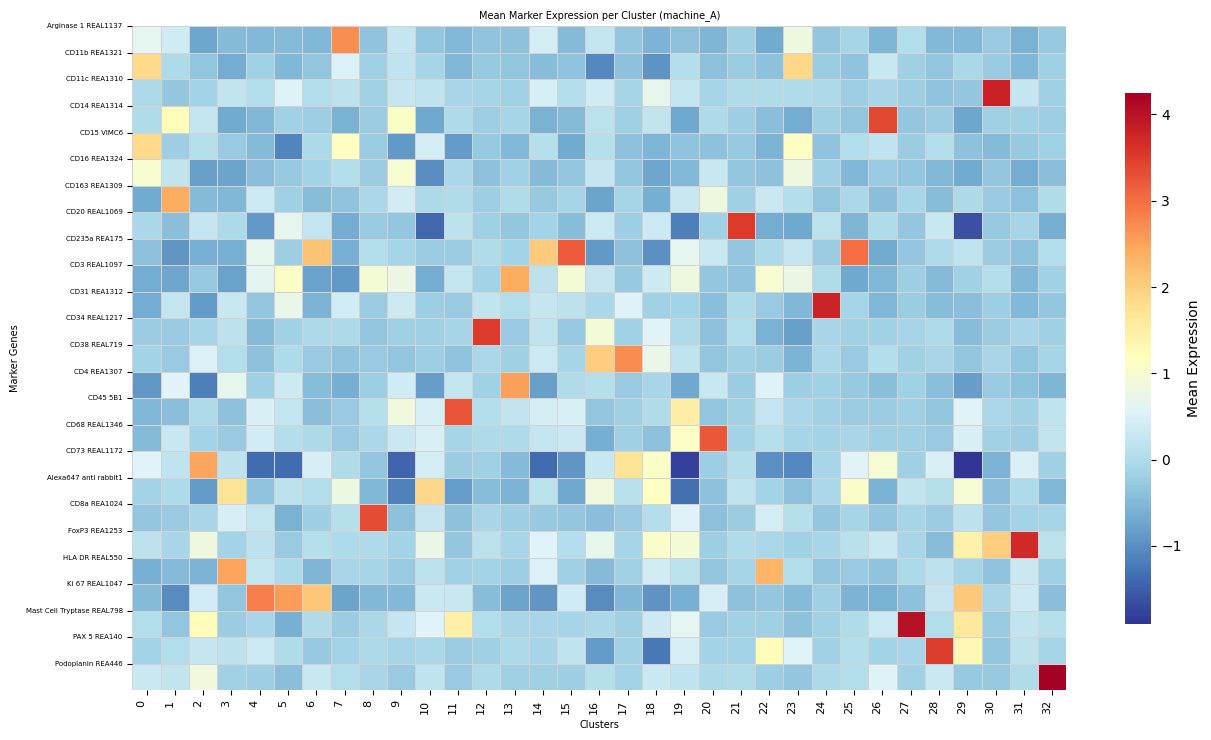

In [13]:
# Compute cluster means
cluster_means = prepare_cluster_means(
    adata, selected_markers, unselected_features, cluster_key="leiden"
)

x_labels = cluster_means.index.tolist()
y_labels = list(selected_markers)
y_labels_all = list(selected_markers) + unselected_features

# Dot plot (selected markers)
plot_dotplot(
    cluster_means, x_labels, y_labels,
    save_path=output_dir / "dotplot.svg",
    title=f"Mean Marker Expression per Cluster ({MACHINE})",
)

# Heatmap (selected markers)
plot_heatmap(
    cluster_means, x_labels, y_labels,
    save_path=output_dir / "heatmap.svg",
    title=f"Mean Marker Expression per Cluster ({MACHINE})",
)

## Top Markers & Save Outputs

In [14]:
# Differential expression: top markers per cluster
top_markers = compute_top_markers(adata, groupby="leiden", top_k=5)
display(top_markers)
top_markers.to_csv(output_dir / "top_markers.csv", index=False)

# Save AnnData
save_adata(adata, output_dir / "adata.h5ad")

# Save per-ROI cluster assignment CSVs
roi_dir = output_dir / "roi_assignments"
save_roi_assignments(adata, roi_dir, region_col="unique_region")

print(f"\n✓ Stage 3 complete for machine '{MACHINE}'")
print(f"  Outputs: {output_dir}")

/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/scanpy/tools/_rank_genes

,group,names,scores,logfoldchanges,pvals,pvals_adj
19,0,CD4 REA1307,-99.449646,3.919413,0.000000e+00,0.000000e+00
4,0,Podoplanin REA446,73.098602,3.369508,0.000000e+00,0.000000e+00
8,0,FoxP3 REA1253,8.903811,0.065496,5.396127e-19,5.865356e-19
7,0,CD20 REAL1069,18.110952,-1.099792,2.611920e-73,3.109428e-73
10,0,Mast Cell Tryptase REAL798,2.353658,-2.037962,1.858972e-02,1.858972e-02
...,...,...,...,...,...,...
800,32,Podoplanin REA446,18.719320,10.359033,3.445139e-78,8.612849e-77
817,32,CD73 REAL1172,-0.835396,4.767499,4.034949e-01,4.585169e-01
814,32,CD3 REAL1097,0.278747,4.698185,7.804391e-01,8.129574e-01
818,32,PAX 5 REA140,-1.404972,4.501320,1.600296e-01,2.105652e-01


Saved AnnData → experiments/exp-04-03-2026/stage3_clustering/machine_A/adata.h5ad
Saved 34 per-ROI assignment files → experiments/exp-04-03-2026/stage3_clustering/machine_A/roi_assignments

✓ Stage 3 complete for machine 'machine_A'
  Outputs: experiments/exp-04-03-2026/stage3_clustering/machine_A
